In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

In [41]:
iris = load_iris()
# Use only sepal length and sepal width (first two columns)
X = iris.data[:, :2]  
y = iris.target
feature_names = iris.feature_names[:2]  # Keep only the first two feature names
target_names = iris.target_names

# Create a DataFrame for easier data manipulation
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, target_names)

# Display the first few rows of the dataset
print("Iris Dataset Preview (using only sepal length and width):")
print(iris_df.sample(5))

Iris Dataset Preview (using only sepal length and width):
     sepal length (cm)  sepal width (cm)     species
62                 6.0               2.2  versicolor
67                 5.8               2.7  versicolor
134                6.1               2.6   virginica
141                6.9               3.1   virginica
97                 6.2               2.9  versicolor


In [42]:
print (iris_df.describe)

<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)    species
0                  5.1               3.5     setosa
1                  4.9               3.0     setosa
2                  4.7               3.2     setosa
3                  4.6               3.1     setosa
4                  5.0               3.6     setosa
..                 ...               ...        ...
145                6.7               3.0  virginica
146                6.3               2.5  virginica
147                6.5               3.0  virginica
148                6.2               3.4  virginica
149                5.9               3.0  virginica

[150 rows x 3 columns]>


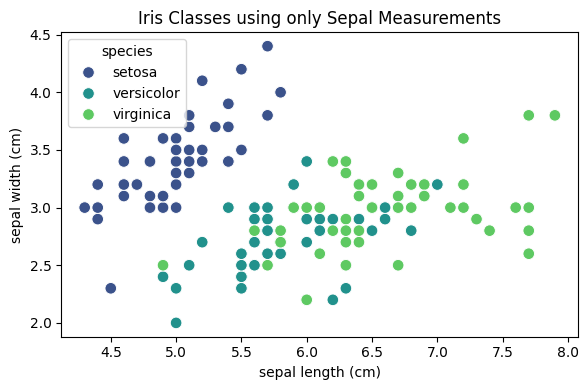

In [43]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=feature_names[0], y=feature_names[1], hue='species', data=iris_df, palette='viridis', s=70)
plt.title('Iris Classes using only Sepal Measurements')
plt.tight_layout()
plt.show()

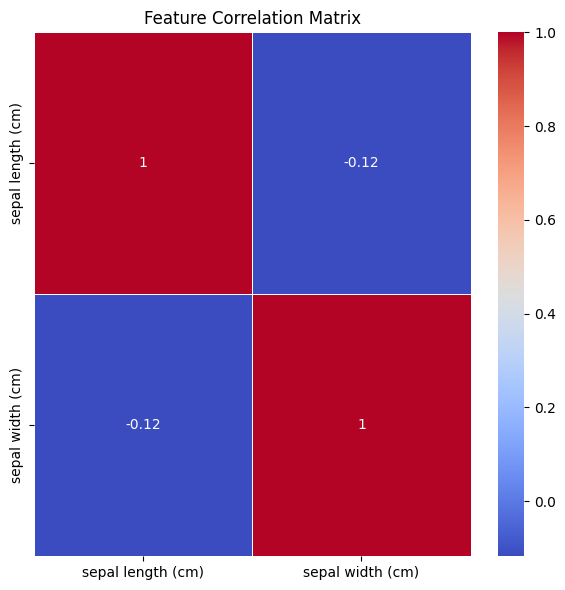

In [44]:
# Correlation matrix
plt.figure(figsize=(6,6))
correlation = iris_df.drop('species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [45]:
# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 105
Testing set size: 45


In [62]:
# Step 4: Create and train a base model (Decision Tree)
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)
base_accuracy = accuracy_score(y_test, base_pred)

print("\n--- Base Model Performance ---")
print(f"Base Decision Tree Accuracy: {base_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, base_pred, target_names=target_names))


--- Base Model Performance ---
Base Decision Tree Accuracy: 0.6667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      0.95      0.97        19
  versicolor       0.43      0.46      0.44        13
   virginica       0.46      0.46      0.46        13

    accuracy                           0.67        45
   macro avg       0.63      0.62      0.63        45
weighted avg       0.68      0.67      0.67        45



In [63]:

# Step 5: Create and train Bagging ensemble with different numbers of estimators
n_estimators_list = [1, 5, 10, 20, 50, 100]
bagging_accuracies = []

for n_estimators in n_estimators_list:
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n_estimators,
        random_state=42,
        bootstrap=True,  # Use bootstrapped samples
        bootstrap_features=False  # Don't use feature sampling
    )
    bagging.fit(X_train, y_train)
    bagging_pred = bagging.predict(X_test)
    bagging_accuracy = accuracy_score(y_test, bagging_pred)
    bagging_accuracies.append(bagging_accuracy)
    
    # Print results for each iteration
    print(f"\n--- Bagging with {n_estimators} estimators ---")
    print(f"Accuracy: {bagging_accuracy:.4f}")


--- Bagging with 1 estimators ---
Accuracy: 0.7111

--- Bagging with 5 estimators ---
Accuracy: 0.7111

--- Bagging with 10 estimators ---
Accuracy: 0.7111

--- Bagging with 20 estimators ---
Accuracy: 0.6889

--- Bagging with 50 estimators ---
Accuracy: 0.7111

--- Bagging with 100 estimators ---
Accuracy: 0.6889


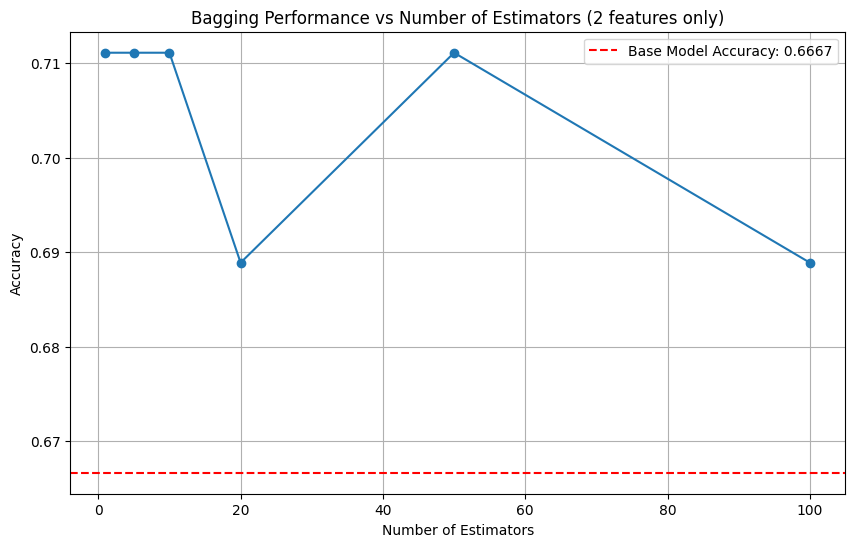

In [48]:
# Step 6: Visualize the impact of the number of estimators
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, bagging_accuracies, marker='o', linestyle='-')
plt.axhline(y=base_accuracy, color='r', linestyle='--', label=f'Base Model Accuracy: {base_accuracy:.4f}')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Bagging Performance vs Number of Estimators (2 features only)')
plt.legend()
plt.grid(True)
plt.show()


--- 10-Fold Cross-Validation Results ---
Base Decision Tree: 0.6733 ± 0.0917
Bagging (1 estimators): 0.6533 ± 0.1108
Bagging (5 estimators): 0.7067 ± 0.0680
Bagging (10 estimators): 0.7067 ± 0.0680
Bagging (20 estimators): 0.7000 ± 0.0683
Bagging (50 estimators): 0.7133 ± 0.0897
Bagging (100 estimators): 0.7333 ± 0.0894


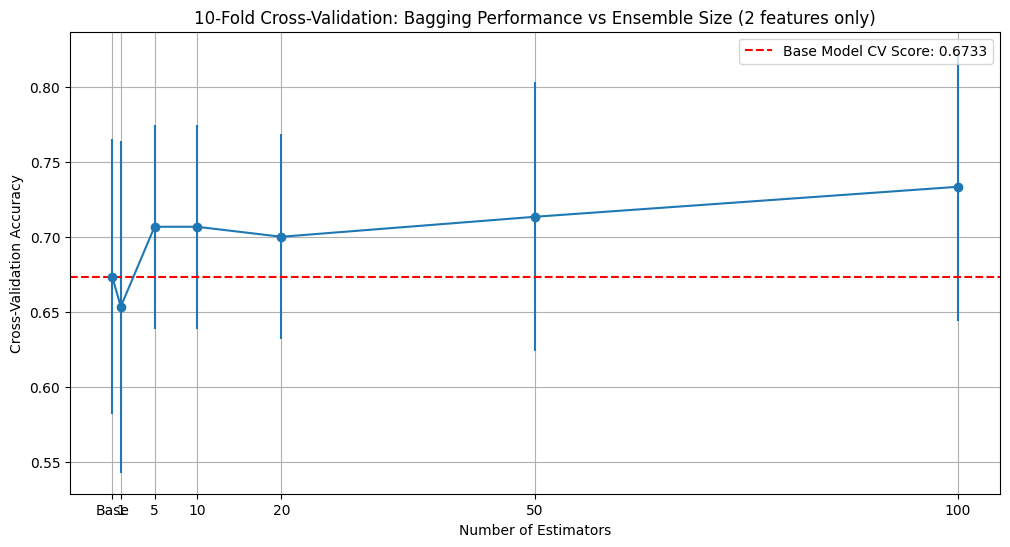

In [50]:
# Step 7: Cross-validation to get more reliable performance estimates
cv_folds = 10
base_cv_scores = cross_val_score(base_model, X, y, cv=cv_folds)

# Compare base model with different bagging sizes using cross-validation
cv_results = []
for n_estimators in n_estimators_list:
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n_estimators,
        random_state=42
    )
    bagging_cv_scores = cross_val_score(bagging, X, y, cv=cv_folds)
    cv_results.append((n_estimators, bagging_cv_scores.mean(), bagging_cv_scores.std()))
    
print(f"\n--- {cv_folds}-Fold Cross-Validation Results ---")
print(f"Base Decision Tree: {base_cv_scores.mean():.4f} ± {base_cv_scores.std():.4f}")
for n_est, mean, std in cv_results:
    print(f"Bagging ({n_est} estimators): {mean:.4f} ± {std:.4f}")

# Plot cross-validation results
plt.figure(figsize=(12, 6))
plt.errorbar(
    [0] + [res[0] for res in cv_results],
    [base_cv_scores.mean()] + [res[1] for res in cv_results],
    yerr=[base_cv_scores.std()] + [res[2] for res in cv_results],
    fmt='o-'
)
plt.axhline(y=base_cv_scores.mean(), color='r', linestyle='--', label=f'Base Model CV Score: {base_cv_scores.mean():.4f}')
plt.xticks([0] + n_estimators_list, ['Base'] + [str(n) for n in n_estimators_list])
plt.xlabel('Number of Estimators')
plt.ylabel('Cross-Validation Accuracy')
plt.title(f'{cv_folds}-Fold Cross-Validation: Bagging Performance vs Ensemble Size (2 features only)')
plt.legend()
plt.grid(True)
plt.show()


--- Best Bagging Model (n_estimators=100) ---
Accuracy: 0.6889

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      0.95      0.97        19
  versicolor       0.46      0.46      0.46        13
   virginica       0.50      0.54      0.52        13

    accuracy                           0.69        45
   macro avg       0.65      0.65      0.65        45
weighted avg       0.70      0.69      0.69        45



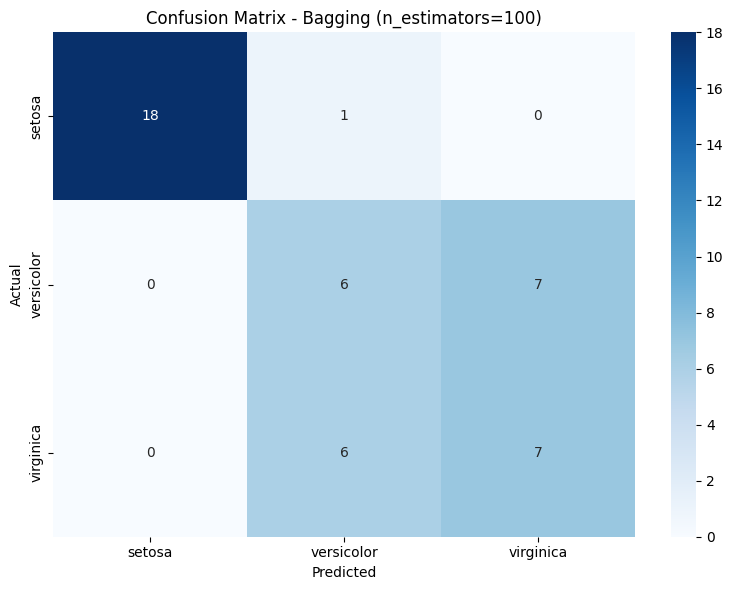

In [52]:
# Step 8: Analyze our best bagging model in detail
best_n_estimators = n_estimators_list[np.argmax([res[1] for res in cv_results])]
best_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=best_n_estimators,
    random_state=42,
    bootstrap=True
)
best_bagging.fit(X_train, y_train)
best_bagging_pred = best_bagging.predict(X_test)

print(f"\n--- Best Bagging Model (n_estimators={best_n_estimators}) ---")
print(f"Accuracy: {accuracy_score(y_test, best_bagging_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_bagging_pred, target_names=target_names))

# Confusion Matrix for the best bagging model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_bagging_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Bagging (n_estimators={best_n_estimators})')
plt.tight_layout()
plt.show()

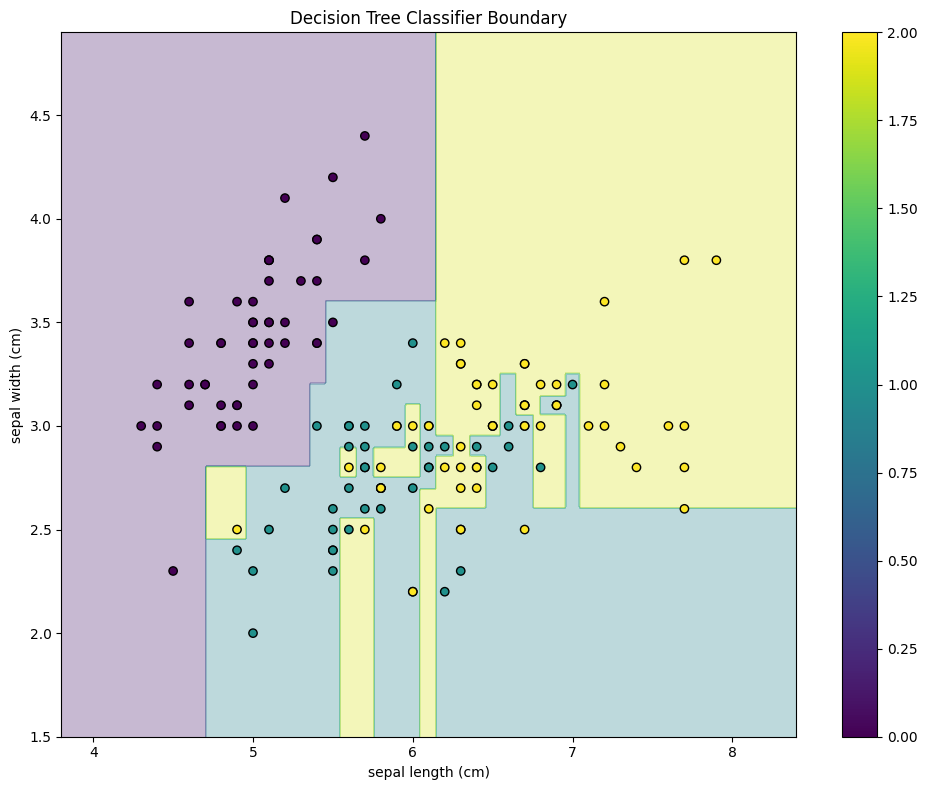

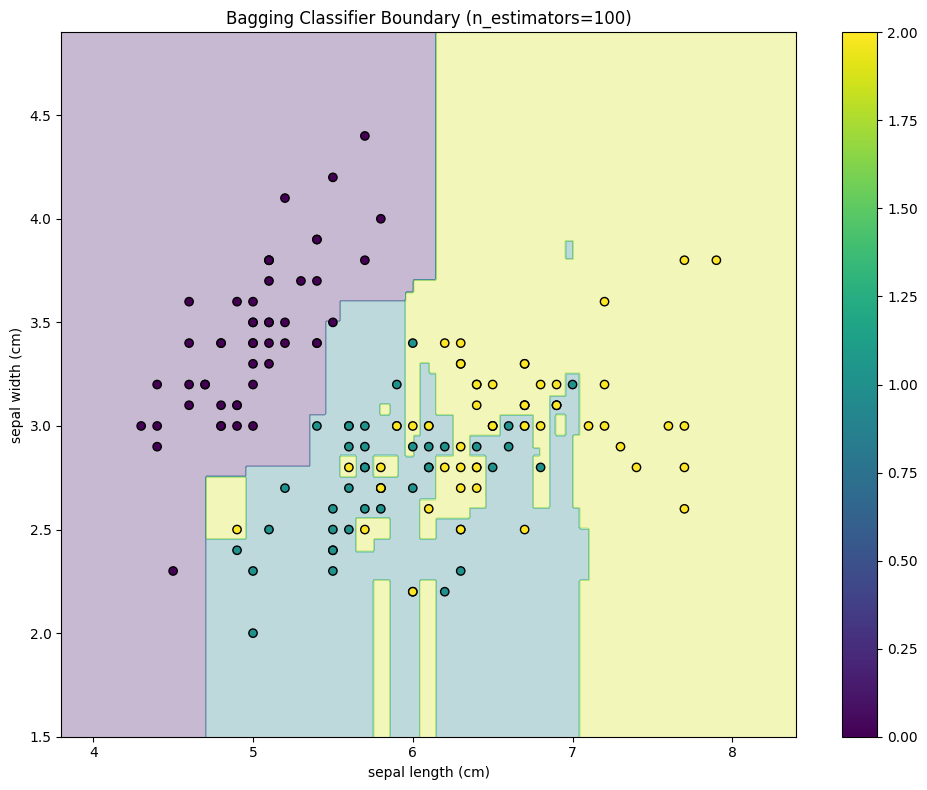

In [53]:
# Step 9: Visualize decision boundaries
def plot_decision_boundaries(X, y, model, title):
    # Set min and max values for both features with some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    # Make predictions on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    
    # Plot the original data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()

# Plot decision boundaries for the base model and best bagging model
plot_decision_boundaries(X, y, base_model, 'Decision Tree Classifier Boundary')
plot_decision_boundaries(X, y, best_bagging, f'Bagging Classifier Boundary (n_estimators={best_n_estimators})')



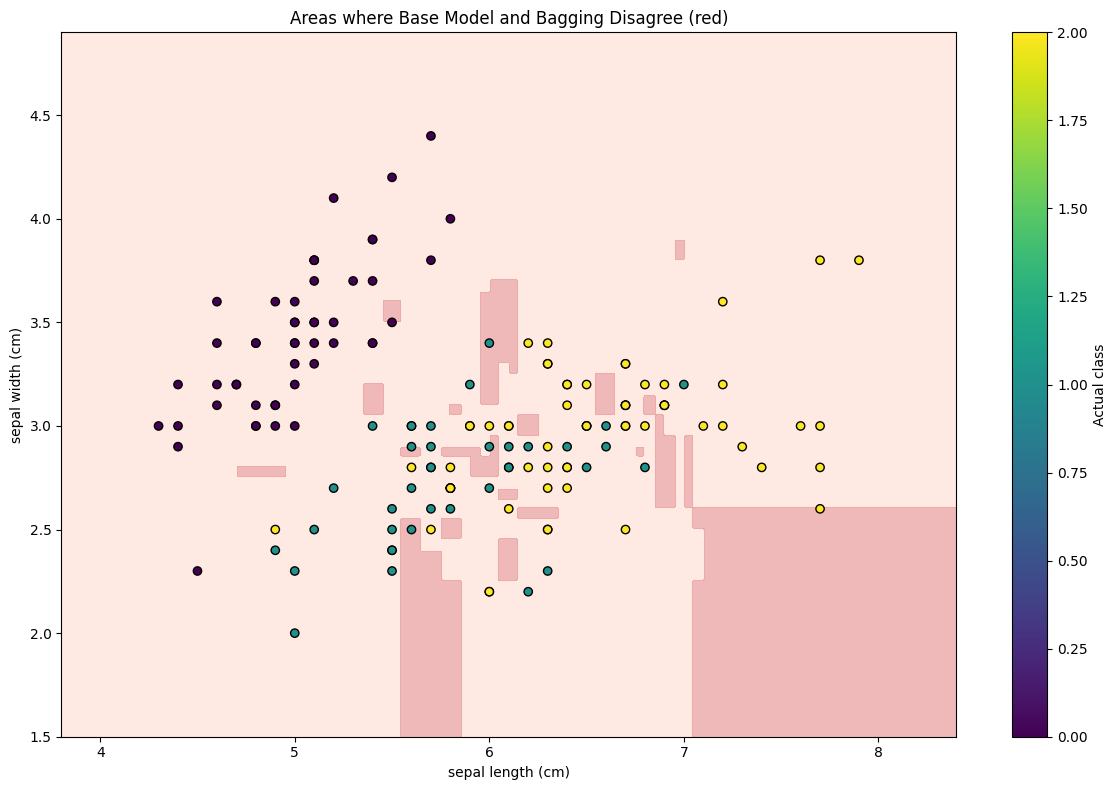

In [54]:
# Step 10: Compare predictions between base model and bagging
# Create a visualization showing where models agree and disagree
plt.figure(figsize=(12, 8))

# Create a meshgrid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Get predictions
base_preds = base_model.predict(grid_points)
bagging_preds = best_bagging.predict(grid_points)

# Create disagreement mask
disagreement = (base_preds != bagging_preds).reshape(xx.shape)

# Plot areas of disagreement
plt.contourf(xx, yy, disagreement, alpha=0.3, cmap='Reds')

# Plot the original data
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
plt.colorbar(scatter, label='Actual class')

# Add labels and title
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Areas where Base Model and Bagging Disagree (red)')
plt.tight_layout()
plt.show()